# CSC 487 Final Project
By: Pranav Krishna, Ahad Jiva, Milad Chabok, Pranav Nallaperumal

*Note*: Ensure you install dependencies with `!pip install -r requirements.txt` or `!pip install -r requirements-cuda.txt` and place your `.env` file containing `GEMINI_API_KEY=your_key` in the project root.

In [95]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import shutil
import kagglehub
from google.genai import types

## Grab data from csv, import to dataframe, split into features and labels

In [96]:
# If dataset not downloaded
path = kagglehub.dataset_download("priyamchoksi/credit-card-transactions-dataset")
print("Path to dataset files:", path)

# move/copy the csv to current directory
for file in os.listdir(path):
    if file.endswith('.csv'):
        source_file = os.path.join(path, file)
        target_file = 'credit_card_transactions.csv'
        if not os.path.exists(target_file):
            shutil.copy(source_file, target_file)
            print(f"Copied {file} to {target_file}")
        else:
            print(f"{target_file} already exists.")
        break


Path to dataset files: C:\Users\Pranav Krishna\.cache\kagglehub\datasets\priyamchoksi\credit-card-transactions-dataset\versions\1
credit_card_transactions.csv already exists.


In [97]:
df = pd.read_csv("credit_card_transactions.csv")

print(df.head())
print(df.columns)

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      long city_pop  \
0    Banks      F                561 Perry Cove  ...  -81.1781     3495   
1     Gill      F  43039 Riley Greens Suite 393  ... -11

## LLM Step format job categories

In [98]:
load_dotenv()

unique_jobs = [j for j in df['job'].unique() if isinstance(j, str)]
cache_file = 'job_encodings.txt'
job_map = None

MAX_LLM_CATEGORIES = 6

print(unique_jobs)

if os.path.exists(cache_file):
    print("Loading cached job encodings...")
    with open(cache_file, 'r', encoding='utf-8') as f:
        job_map = json.load(f)
        if(job_map['mappings'] == {}):
            job_map = None

if(job_map == None):
    print("Calling Gemini API to encode job categories...")
    genai.configure(api_key=os.environ.get("GEMINI_API_KEY"))
    
    # As requested: Gemini 3 Flash preview
    model = genai.GenerativeModel('gemini-3-flash-preview')
    
    prompt = f"""Categorize the following job titles into much broader categories, not exceeding {MAX_LLM_CATEGORIES} categories.
                 Assign each a numeric category ID from 0 to X. 
                 Return ONLY a valid JSON dictionary which has two parts.
                 The first part `categories` is the categories you generated along with their key.
                 The second part `mappings` are the exact job titles from my data which are mapped to their numeric ID of the more
                 broad categories you generated. 
                 Jobs to categorize:\n{unique_jobs}"""
    
    response = model.generate_content(
        prompt,
        generation_config=genai.GenerationConfig(
            response_mime_type="application/json",
        )
    )
    
    try:
        job_map = json.loads(response.text.strip())
        with open(cache_file, 'w', encoding='utf-8') as f:
            json.dump(job_map, f, ensure_ascii=False, indent=4)
        print(f"Saved job encodings to {cache_file}")
    except Exception as e:
        print(f"Failed to parse JSON: {e}")
        print(response.text)
        job_map = {job: 0 for job in unique_jobs}

# Map to the dataframe
if(job_map['mappings'] != {}):
    df['job'] = df['job'].map(job_map['mappings']).fillna(0).astype('int64')


['Psychologist, counselling', 'Special educational needs teacher', 'Nature conservation officer', 'Patent attorney', 'Dance movement psychotherapist', 'Transport planner', 'Arboriculturist', 'Designer, multimedia', 'Public affairs consultant', 'Pathologist', 'IT trainer', 'Systems developer', 'Engineer, land', 'Systems analyst', 'Naval architect', 'Radiographer, diagnostic', 'Programme researcher, broadcasting/film/video', 'Energy engineer', 'Event organiser', 'Operational researcher', 'Market researcher', 'Probation officer', 'Leisure centre manager', 'Corporate investment banker', 'Therapist, occupational', 'Call centre manager', 'Police officer', 'Education officer, museum', 'Physiotherapist', 'Network engineer', 'Forensic psychologist', 'Geochemist', 'Armed forces training and education officer', 'Designer, furniture', 'Optician, dispensing', 'Psychologist, forensic', 'Librarian, public', 'Fine artist', 'Scientist, research (maths)', 'Research officer, trade union', 'Tourism office

In [99]:
X = df.loc[:, ~df.columns.isin(["is_fraud", "Unnamed: 0"])].select_dtypes(include=np.number)
y = df["is_fraud"]

X, y

print(X.columns)
print(df.loc[:, ~df.columns.isin(["is_fraud", "Unnamed: 0"])].columns)


Index(['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'job', 'unix_time',
       'merch_lat', 'merch_long', 'merch_zipcode'],
      dtype='str')
Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'merch_zipcode'],
      dtype='str')


## Remove bad values and check for empty values

In [100]:
bad = X.isna().any(axis=1)
X = X[~bad]
y = y[~bad]

na_x = X.isna().sum(axis=0)
na_y = y.isna().sum(axis=0)

print(na_x, na_y)

cc_num           0
amt              0
zip              0
lat              0
long             0
city_pop         0
job              0
unix_time        0
merch_lat        0
merch_long       0
merch_zipcode    0
dtype: int64 0


## Turning them into np arrays

In [101]:

X = X.values.astype('float32')
y = y.values.astype('int64')

## Convert to Torch tensors

In [102]:
# lster on

## Convert to tensor dataset, train test split

In [103]:
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

#tryna avoid data leakage
avg = X_train.mean(axis=0, keepdims=True)
stdev = X_train.std(axis=0, keepdims=True)

X_train = (X_train - avg) / stdev
X_test = (X_test - avg) / stdev


X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).long()
X_test = torch.tensor(X_test).float()
y_test = torch.tensor(y_test).long()

train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=2048, shuffle=True)
test_loader = DataLoader(test_data, batch_size=2048, shuffle=False)

c:\Pranav Files\College Work\CSC 487\Final\.venv\Lib\site-packages\numpy\_core\_methods.py:201: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


## Model Architecture

In [104]:
device = 'cpu'
if(torch.backends.mps.is_available()):
    print("Using mps")
    device = 'mps'
elif(torch.cuda.is_available()):
    print("Using cuda")
    device = 'cuda'
else:
    print("Using CPU")

linear_model = torch.nn.Sequential(
    torch.nn.Linear(11, 512),
    torch.nn.GELU(),
    torch.nn.Linear(512, 2048),
    torch.nn.GELU(),
    torch.nn.Linear(2048, 1024),
    torch.nn.GELU(),
    torch.nn.Linear(1024, 256),
    torch.nn.GELU(),
    torch.nn.Linear(256, 32),
    torch.nn.GELU(),
    torch.nn.Linear(32, 2)
).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
lr = 3e-4
opt = torch.optim.AdamW(linear_model.parameters(), lr=lr)

Using cuda


In [105]:
for epoch in range(25):
    pbar = tqdm(train_loader, desc=f'Epoch: {epoch}')
    for batch in pbar:
        X_batch, y_batch = batch
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        pred = linear_model(X_batch)
        loss = loss_fn(pred, y_batch)
        opt.zero_grad()
        loss.backward()
        opt.step()
        pbar.set_postfix({'loss': loss.item()})

Epoch: 24: 100%|██████████| 430/430 [00:14<00:00, 30.36it/s, loss=0.0271] 


Predicting...: 100%|██████████| 108/108 [00:02<00:00, 42.09it/s]


Accuracy: 0.9946307139515129


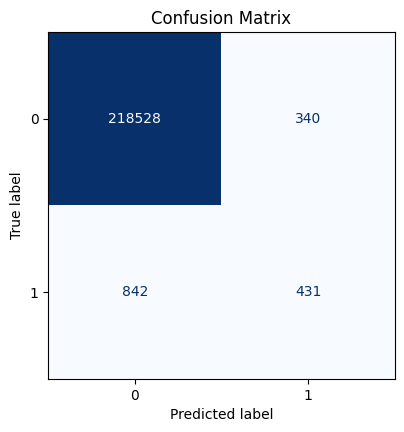

In [106]:
linear_model.eval()

correct = 0
total = 0

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc="Predicting..."):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        pred = linear_model(X_batch)
        predicted_labels = pred.argmax(dim=1)

        y_true.append(y_batch.cpu())
        y_pred.append(predicted_labels.cpu())

        correct += (predicted_labels == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print(f"Accuracy: {accuracy}")

# Confusion matrix (sklearn)
y_true = torch.cat(y_true).numpy()
y_pred = torch.cat(y_pred).numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix")
plt.show()

In [107]:
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn) if (tp + fn) else 0.0
precision = tp / (tp + fp) if (tp + fp) else 0.0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0
total_fraud = y_test.sum()

print(
    f"total fraud: {total_fraud}\n"
    f"true positives: {tp}\n"
    f"true negatives: {tn}\n"
    f"false positives: {fp}\n"
    f"false negatives: {fn}\n"
    f"precision: {precision}\n"
    f"recall: {recall}\n"
    f"f1: {f1}\n"
    f"% of fraudulent transactions in test set classified incorrectly: {fn / total_fraud}"
)

total fraud: 1273
true positives: 431
true negatives: 218528
false positives: 340
false negatives: 842
precision: 0.5590142671854734
recall: 0.33857030636292224
f1: 0.4217221135029355
% of fraudulent transactions in test set classified incorrectly: 0.6614297032356262
